In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import arviz as az

sns.set_context("talk")
plt.style.use("ggplot")

In [2]:
idata = catalog.load("read_time_idata")
idata

                    INFO     Loading data from read_time_idata (PickleDataset)...              ]8;id=535535;file:///Users/matt/Projects/mccabemp/.pixi/envs/default/lib/python3.10/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=481642;file:///Users/matt/Projects/mccabemp/.pixi/envs/default/lib/python3.10/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

Inference data with groups:
        > posterior
        > sample_stats
        > observed_data

Warmup iterations saved (warmup_*).

In [3]:
clean_idata = idata.sel(chain=[1,2,3])

                    WARNING  /Users/matt/Projects/mccabemp/.pixi/envs/default/lib/python3.10/site-p ]8;id=996940;file:///Users/matt/Projects/mccabemp/.pixi/envs/default/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=658878;file:///Users/matt/Projects/mccabemp/.pixi/envs/default/lib/python3.10/warnings.py#109\109]8;;\
                             ackages/arviz/plots/traceplot.py:223: UserWarning:                                    
                             rcParams['plot.max_subplots'] (20) is smaller than the number of                      
                             variables to plot (24), generating only 20 plots                                      
                               warnings.warn(                                                                      
                                                                                                                   

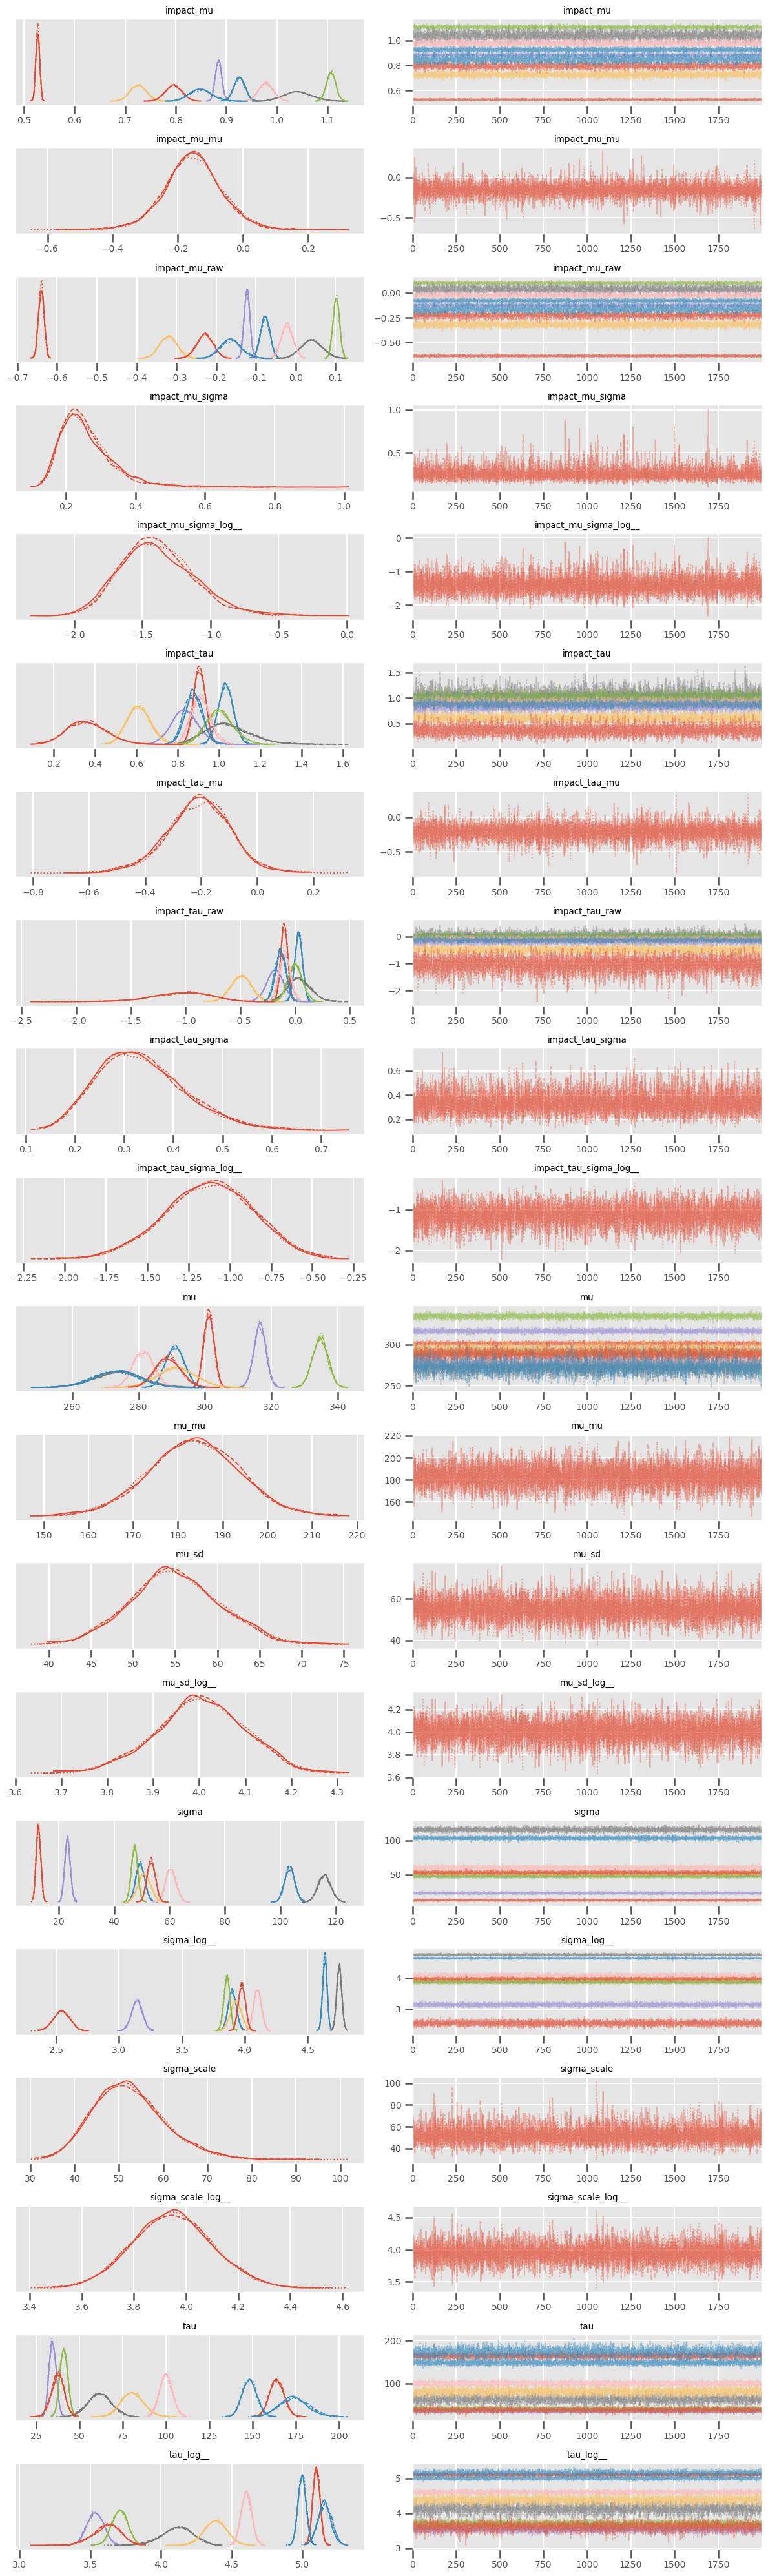

In [4]:
az.plot_trace(clean_idata)
plt.tight_layout()

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

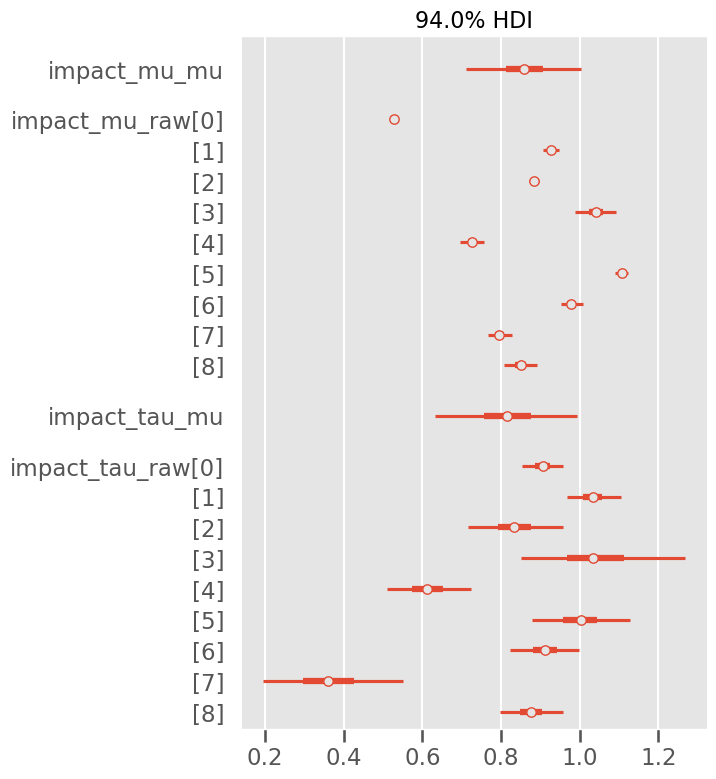

In [9]:
az.plot_forest(
    clean_idata,
    var_names=[
        "impact_mu_mu",
        "impact_mu_raw",
        "impact_tau_mu",
        "impact_tau_raw"
    ],
    combined=True,
    transform=np.exp
)

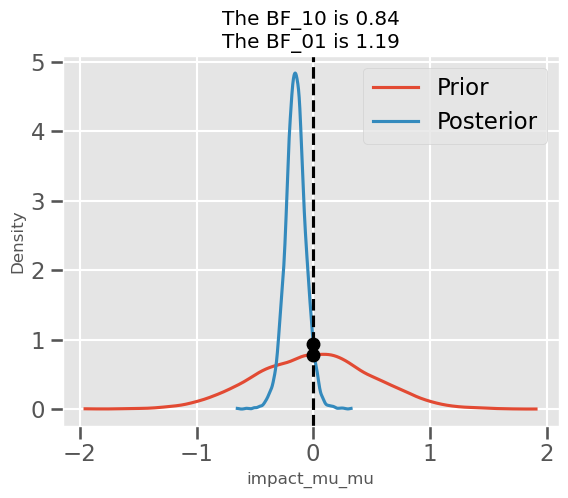

In [6]:
_ = az.plot_bf(clean_idata, var_name="impact_mu_mu", prior=np.random.normal(0, 0.5, size=10_000))

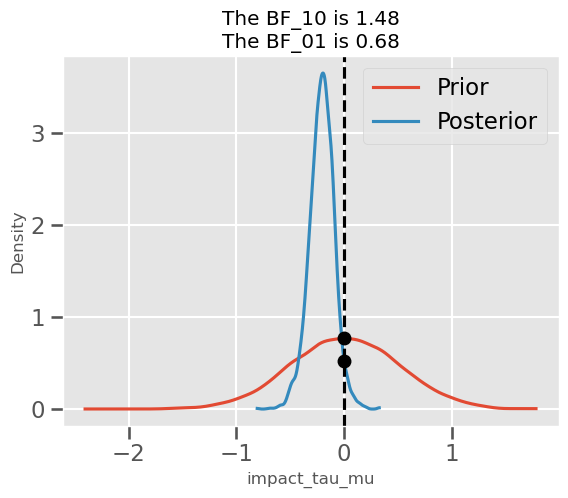

In [8]:
_ = az.plot_bf(clean_idata, var_name="impact_tau_mu", prior=np.random.normal(0, 0.5, size=10_000))